# Imports

In [9]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt

# Animation
from matplotlib import animation

# Typing
from typing import Callable

# Definitions

In [10]:
# Energy scale (we also have a = 1)
t = 1


# Dispersion for a cubic TB model with NN only
def epsilon(kx: float | np.ndarray = np.pi/2, ky: float | np.ndarray = np.pi/2, kz: float | np.ndarray = np.pi/2):
    return -2 * t * (np.cos(kx) + np.cos(ky) + np.cos(kz))


# Compute Ek
def spectral(eps: float | np.ndarray, mu: float, U: float, ne: float) -> tuple:

    # Compute E+-
    Ep = eps - mu + U
    Em = eps - mu

    Zp = ne/2 * (eps/eps)
    Zm = (1 - ne/2) * (eps/eps)

    return Ep, Em, Zp, Zm


def nascent_delta(x: float | np.ndarray, gam: float, func: int = 1) -> float | np.ndarray:
    
    if func == 1:
        return gam / (np.pi * (x * x + gam * gam))
    elif func == 2:
        return np.exp(-x * x / (gam * gam)) / (gam * np.sqrt(np.pi))
    else:
        return -1.0

# Compute DOS

## Tight-Binding in 1D 

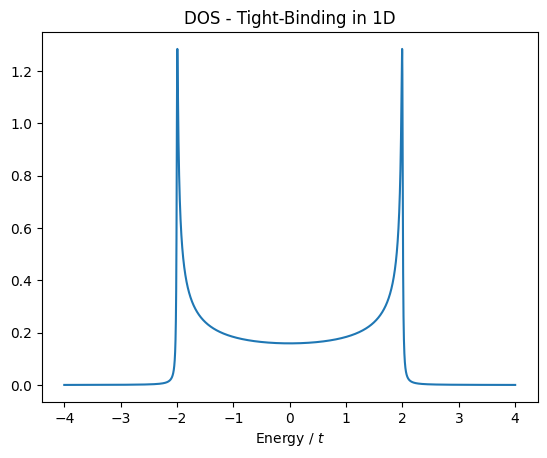

In [11]:
# Physical Parameters
N = 4000

U = 0
mu = 0
ne = 1


# Plotting Parameters
emin = -4
emax = +4

points = 40000
gam = 0.01


omega = np.linspace(emin, emax, points)
dos = np.zeros_like(omega)
for m in range(0, N):
    # Compute energy for this k
    ek = epsilon(2 * np.pi * m / N, np.pi/2, np.pi/2)

    # Add a delta at this energy
    dos += nascent_delta(omega - ek, gam, 1) / N


plt.title("DOS - Tight-Binding in 1D")
plt.xlabel("Energy / $t$")
plt.plot(omega, dos)

## Hubbard Model

In [12]:
def compute_dos(spectral: Callable, ee: np.ndarray, U: float, ne: float, mu: float, points: int, gam: float):
    # Compute dispersion relation
    eepp, eemm, zzpp, zzmm = spectral(ee, mu, U, ne)

    # Flatten the arrays (ravel makes a view, not a copy)
    eepp, eemm, zzpp, zzmm = eepp.ravel(), eemm.ravel(), zzpp.ravel(), zzmm.ravel()

    # Determine range
    emin = np.min(eemm) - 0.5
    emax = np.max(eepp) + 0.5

    # Setup arrays for ploting
    omega = np.linspace(emin, emax, points)
    dos = np.zeros_like(omega)

    # Compute DOS
    for Ep, Em, Zp, Zm in zip(eepp, eemm, zzpp, zzmm):
        dos += Zp * nascent_delta(omega - Ep, gam)
        dos += Zm * nascent_delta(omega - Em, gam)

    return eepp, eemm, zzpp, zzmm, omega, dos


def compute_hubbard(dispersion: Callable, N: int, U: float, ne: float, points: int, gam: float, n: int = 1, text: bool = False):

    # Evaluate the dispersion for a k-grid
    if n == 2:
        kx = 2.0 * np.pi * np.arange(N) / N
        ky = 2.0 * np.pi * np.arange(N) / N
        kz = np.pi/2

        kx, ky = np.meshgrid(kx, ky)

    else:
        kx = 2.0 * np.pi * np.arange(N) / N
        ky = kz = np.pi/2
    
    ee = dispersion(kx, ky, kz)

    # Compute DOS with mu = 0
    eepp, eemm, zzpp, zzmm, omega, dos = compute_dos(spectral, ee, U, ne, mu=0, points=points, gam=gam)

    # Integrate DOS 
    h = omega[1] - omega[0]
    aa = (dos[:-1] + dos[1:]) / 2
    idos = h * np.concatenate((np.array([0]), aa.cumsum()))

    # Normalize to 2
    ndos = (2 / idos[-1])
    idos *= ndos

    # Highest filled state and lowest empty state
    # Because of the finite width Dirac delta there is some DOS in the gap
    filled = omega[idos <= ne]
    empty = omega[idos >= ne]

    # Determine chemical potential at T = 0
    # It is midway between the last filled level and last unfilled level
    mu = 0.5 * (filled[-1] + empty[0])

    # Compute DOS with correct mu
    eepp, eemm, zzpp, zzmm, omega, dos = compute_dos(spectral, ee, U, ne, mu, points, gam)

    # Normalize to 2
    dos *= ndos

    # Compute gap via DOS
    # This is too senstive to gamma parameter in nascent delta
    highdos = omega[dos > 5e-3]
    deltados = np.max(highdos[1:] - highdos[:-1])

    # Compute gap via bands
    delta = max(0, np.min(eepp) - np.max(eemm))

    # Show analysis
    if text:

        # Sanity Checks
        print("Weights add to 1? ", np.allclose(zzpp + zzmm, 1.0))
        print(f"Range of E-: [{np.min(eemm):.4f}, {np.max(eemm):.4f}]")
        print(f"Range of E+: [{np.min(eepp):.4f}, {np.max(eepp):.4f}]")
        print("\n")

        # Integral over each band
        if np.max(eemm) < np.min(eepp):
            print("Bands are separate!")

            midpoint = (np.max(eemm) + np.min(eepp)) / 2

            maskm = omega < midpoint
            maskp = omega > midpoint

            print("Integral of DOS over lower band:", np.trapezoid(dos[maskm], omega[maskm]))
            print("Integral of DOS over upper band:", np.trapezoid(dos[maskp], omega[maskp]))


    return kx, eepp, eemm, zzpp, zzmm, omega, dos, mu, delta



def visualize_hubbard(dispersion: Callable, N: int, U: float, ne: float, points: int, gam: float, n: int = 1, text: bool = False):
    # Get plot
    kx, eepp, eemm, zzpp, zzmm, omega, dos, mu, delta = compute_hubbard(epsilon, N, U, ne, points, gam, n, text)


    # Make a side-by-side plot: bands (left) and DOS (right)
    if n == 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=True, gridspec_kw={'width_ratios': [1.5, 1]})

        # Upper band with Z+ as color
        sc1 = ax1.scatter(kx, eepp, c=zzpp, cmap='Blues', vmin=0, vmax=1, s=2, label=r"$E_k^+$")

        # Lower band with Z- as color
        sc2 = ax1.scatter(kx, eemm, c=zzmm, cmap='Reds', vmin=0, vmax=1, s=2, label=r"$E_k^-$")


        # --- Density of States ---
        ax2.plot(dos, omega / t, 'k-')
        ax2.set_xlabel('DOS (states / E)')
        ax2.set_title(rf'Density of States ($\Delta$ = {delta:.4f})')

        # Text of the plot
        ax1.set_xlabel(r'$k$')
        ax1.set_ylabel('Energy / t')
        # ax1.set_title(f'Bands for U={U:.2f}, ne={ne:.2f} and mu={mu:.2f}')
        ax1.set_title(f'Poles for 1D chain with U={U:.0f}, ne={ne:.0f} and mu={mu:.2f}')
        ax1.legend(frameon=False, loc="upper right")
    
    # Plot DOS only
    else:
        plt.plot(omega/t, dos)
        plt.xlabel('Energy / t')
        plt.ylabel('DOS (states / E)')
        plt.title(rf'DOS for U={U:.2f}, ne={ne:.2f} and mu={mu:.2f} ($\Delta$ = {delta:.4f})')


    # Make layout nice
    plt.tight_layout()
    plt.show()

### Model in 1D

Weights add to 1?  True
Range of E-: [-4.5000, -0.5000]
Range of E+: [0.5000, 4.5000]


Bands are separate!
Integral of DOS over lower band: 0.9999940901149675
Integral of DOS over upper band: 0.9999940901149678


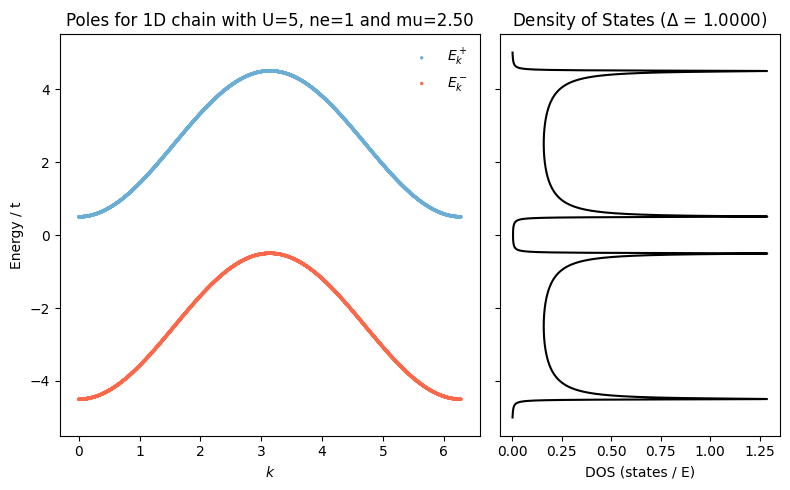

In [13]:
# Example
N = 4000
U = 5
ne = 1

visualize_hubbard(epsilon, N, U, ne, points=4000, gam=0.01, n=1, text=True)

### Model in 2D

Weights add to 1?  True
Range of E-: [-4.0500, 3.9500]
Range of E+: [-3.9500, 4.0500]




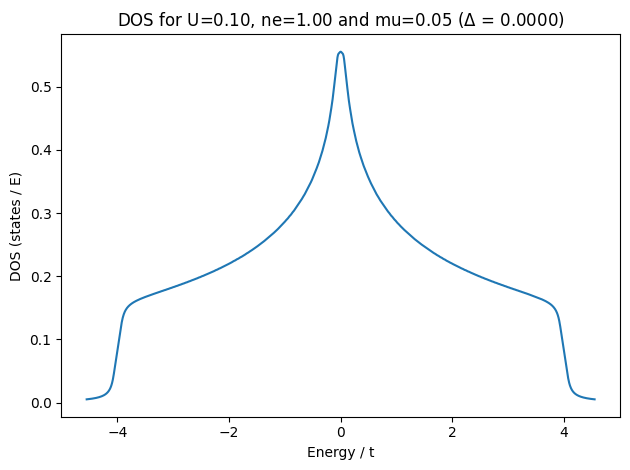

In [14]:
# Example
N = 200
U = 0.1
ne = 1

visualize_hubbard(epsilon, N, U, ne, points=2000, gam=0.05, n=2, text=True)

### Generate Data for Analysis (and GIFs)

In [15]:
# Parameters
N = 4000
ne = 1
n = 1

Umin = 0
Umax = 10
Usteps = 40
uu = np.linspace(Umin, Umax, Usteps)


# Resolution
points = 2000
gam = 0.01


# Compute data
results = []
for U in uu:
    kx, eepp, eemm, zzpp, zzmm, omega, dos, mu, delta = compute_hubbard(epsilon, N, U, ne, points, gam, n)
    results.append((kx, eepp, eemm, zzpp, zzmm, omega, dos, U, mu, delta))

# Minimum U that makes a gap appear
mini = -1
for index, U in enumerate(uu):
    # Unpack data
    kx, eepp, eemm, zzpp, zzmm, omega, dos, U, mu, delta = results[index]

    # Check gap
    if delta > 0:
        mini = index
        break


if mini == -1:
    print("There is no gap!")

# Overestimating smallest U at which there is a gap!
else:
    print(f"The gap appears at U = {uu[mini]} (index = {mini})")

The gap appears at U = 4.102564102564102 (index = 16)


### GIFs

In [16]:
# --- Update rule ---
def update(frame, ax1, ax2, scatters, lines, results, n):
    # Unpack data
    kx, eepp, eemm, zzpp, zzmm, omega, dos, U, mu, delta = results[frame]

    # Make a side-by-side plot: bands (left) and DOS (right)
    if n == 1:
        # Update scatter data (bands with Z color)
        scatters['eepp'].set_offsets(np.c_[kx, eepp])
        scatters['eepp'].set_array(zzpp)

        scatters['eemm'].set_offsets(np.c_[kx, eemm])
        scatters['eemm'].set_array(zzmm)

        # Update DOS line
        lines['dos'].set_data(dos, omega / t)

        # Update title
        ax1.set_title(f'Bands for U={U:.2f}, ne={ne} and mu={mu:.2f}')
        ax2.set_title(rf'Density of States ($\Delta$ = {delta:.4f})')
    
    # Plot DOS only
    else:
        lines['dos'].set_data(omega/t, dos)
        ax1.set_title(rf'DOS for U={U:.2f}, ne={ne:.2f} and mu={mu:.2f} ($\Delta$ = {delta:.4f})')
        
    return list(scatters.values()) + list(lines.values())



def makeGIF(results: list, N: int, ne: float, n: int):
    
    # First frame
    kx, eepp, eemm, zzpp, zzmm, omega, dos, U, mu, delta = results[0]

    # One-dimension: Show bands and DOS
    if n == 1:
        # Start the plot
        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(8, 5), sharey=True, gridspec_kw={'width_ratios': [1.5, 1]}
        )
        ax1.set_xlabel(r'$k$')
        ax1.set_ylabel('Energy / t')
        ax1.set_ylim(-1.5 - Umax, 1.5 + Umax)
        ax2.set_xlabel('DOS (arb. units)')


        # Initialize scatter objects (with color encoding)
        scatters = {
            'eepp': ax1.scatter(kx, eepp, c=zzpp, cmap='Blues', vmin=0, vmax=1, s=2, label=r"$E_k^+$"),
            'eemm': ax1.scatter(kx, eemm, c=zzmm, cmap='Reds', vmin=0, vmax=1, s=2, label=r"$E_k^-$")
        }

        # Initialize DOS line
        lines = {
            'dos': ax2.plot(dos, omega / t, 'k-')[0]
        }

        # Legend
        ax1.legend(frameon=False, loc="upper right")
    
    # More then one dimension: Show only DOS
    else:
        # Start the plot
        fig, ax1 = plt.subplots()

        ax1.set_xlabel('Energy / t')
        ax1.set_ylabel('DOS (states / E)')
        
        ax1.set_xlim(-(2 + Umax), 2 + Umax)
        ax1.set_ylim(-0.05, np.max(dos) + 0.1)
        

        # Initialize DOS line
        lines = {
            'dos': ax1.plot(omega / t, dos)[0]
        }

        # Dummy variables
        ax2 = None
        scatters = {}
                

    # Animate
    ani = animation.FuncAnimation(fig, update, frames=len(results), fargs=(ax1, ax2, scatters, lines, results, n), interval=300)
    ani.save(f"02-Hubbard-{N}-{ne}.gif", writer="pillow")
    plt.close()


makeGIF(results, N, ne, n)